In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import sympy as smp

In [2]:
torch.set_default_device('mps')
torch.set_default_dtype(torch.float32)

The PDE we are solving reads
$$\alpha^2 y(\theta) = -\frac{\partial^2 y(\theta)}{\partial \theta},$$
and we are working on a circle, which implies that $\theta = \theta + 2\pi$. For the rest, we fix an arbitrary value for $\alpha=1$.
We train a PINN, that gets us a solution for the equation.  We want to build a Finite Differences solver that solves thhis equation. We fix a $\theta_0$ value.

In [19]:
alpha = 1.
theta0 = torch.tensor(0.96303)
dtheta = 1e-4
t_range = 2*torch.pi

In [20]:
thetas = torch.linspace(0, t_range, int(t_range/dtheta))

In [21]:
y = 1/torch.pi**0.5 * torch.cos(alpha*(thetas-theta0))

In [22]:
def fd_solver(y0, y1, dtheta, t):
    ys = [y0, y1]
    for _ in tqdm(range(int(t/dtheta)-2)):
        ys.append((-alpha**2)*ys[-1]*dtheta**2+2*ys[-1]-ys[-2])
    return ys

In [24]:
y_hat = fd_solver(y[0].item(), y[1].item(), dtheta, t_range)

  0%|          | 0/62829 [00:00<?, ?it/s]

In [25]:
y_hat = torch.tensor(y_hat)

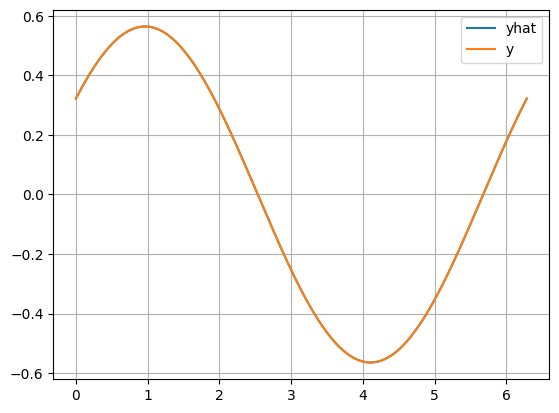

In [26]:
plt.plot(thetas.cpu(), y_hat.cpu(), label="yhat")
plt.plot(thetas.cpu(), y.cpu(), label="y")
plt.legend()
plt.grid()
plt.show()

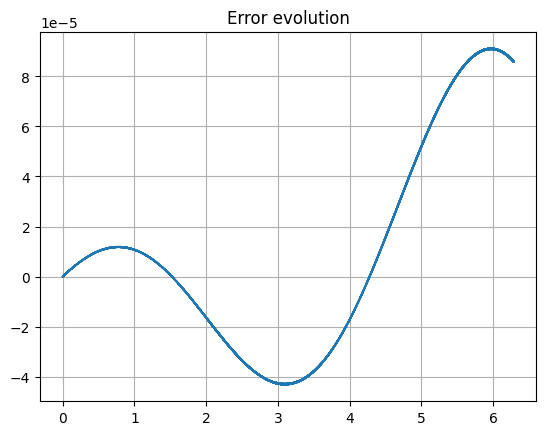

In [27]:
plt.plot(thetas.cpu(), (y-y_hat).cpu())
plt.title("Error evolution")
plt.grid()
plt.show()

The local error is bounded to $O(d\theta^2)$. This truncation error (theoretically) should expand linearly with the number of steps, yielding a bound on the distribution of the error of $O(N d\theta^2) = O(t d\theta)$.

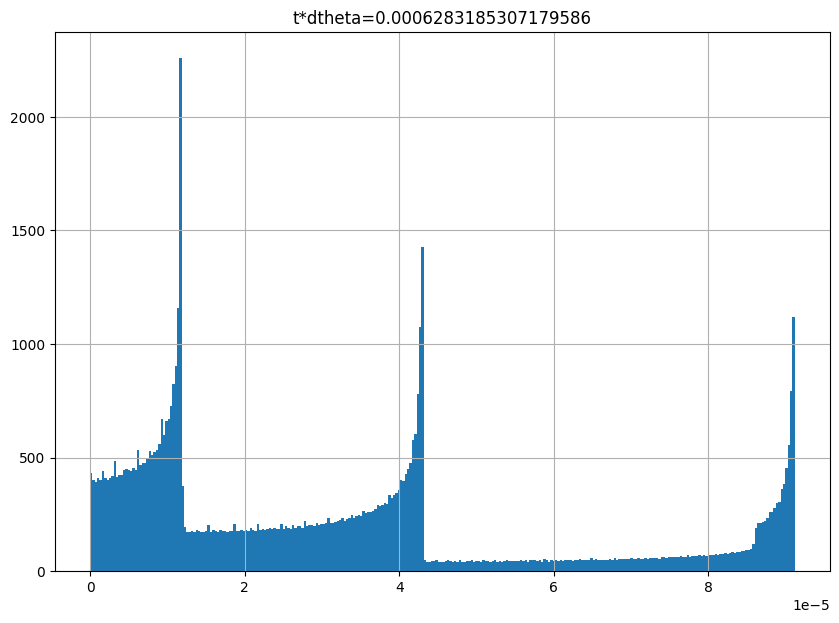

In [29]:
plt.figure(figsize=(10, 7))
plt.hist(torch.abs(y-y_hat).cpu(), bins=300)
plt.title(f"t*dtheta={t_range*dtheta}")
plt.grid()
plt.show()

Now, the question is to know if a PINN trained on data with the same discretization has the same distribution of error.

## Non-linear case
Let now $p>2$ be fixed (say, $p=\pi$), we have
$$ 
    -y'' = y|y|^{p-2} \tag{3'}.
$$
The FD solver reads

In [42]:
def fd_solver(y0, y1, dtheta, theta_range, p):
    res = [y0, y1]
    for _ in tqdm(range(int(theta_range/dtheta)-2)):
        res.append(-res[-1]*abs(res[-1])**(p-2) * dtheta**2 + 2*res[-1] - res[-2])
    return res

In [43]:
alpha = 1.
p = 2*torch.pi
x = smp.symbols('x')
expr = 1 / smp.sqrt(1 - x**p)
result = smp.integrate(expr, (x, 0, 1))
integral = float(smp.simplify(result))
kappa_alpha = ((2**0.5)/torch.pi * (p**(1/p)) * integral)**(2*p/(p-2)) * alpha**((2*p/(p-2)))

In [44]:
dtheta = 1e-3
t_range = 2*torch.pi
thetas = torch.linspace(0, t_range, int(t_range/dtheta))

  0%|          | 0/6281 [00:00<?, ?it/s]

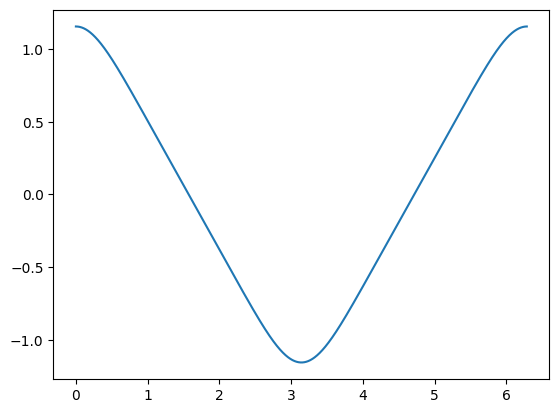

In [46]:
y_hat = fd_solver((p*kappa_alpha)**(1/p), (p*kappa_alpha)**(1/p), dtheta, t_range, p=p)
plt.plot(thetas.cpu(), y_hat)